# Functional FQI: paper results and empirical identification

Kernel: **Python 3** in the package analysis environment. This walkthrough is for
readers familiar with Monte Carlo evaluation and FQI. It reconstructs coefficient
selection, uncertainty, and critic diagnostics from released simulation results;
it does not retrain the paper models. Full GPU commands are in `docs/reproducibility.md`.

1. Load the per-run results.
2. Reconstruct tuning-only selections and reporting means.
3. Bootstrap whole training seeds.
4. Inspect actual adjacent-critic energies and action distances.
5. Generate the six paper figures.

In [1]:
# Locate the package by its marker, without assuming an absolute directory.
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'project_config.json').is_file())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import pandas as pd
from IPython.display import display, Image
SOURCE = ROOT / 'results/source'
tuning = pd.read_csv(SOURCE / 'tuning_candidate_values.csv')
report = pd.read_csv(SOURCE / 'reporting_values.csv')
print({'candidate_fits': len(tuning), 'independent_reporting_fits': len(report)})

{'candidate_fits': 1000, 'independent_reporting_fits': 360}


## Tuning is separate from reporting

Within each approximator / sample size / seed, choose the coefficient with the
largest tuning mean. Exact ties favor smaller coefficients. Report the independent
reporting mean, not the tuning objective. Policy-curvature selection uses
simulator tuning returns; KRR critic ridge is selected separately by subject-grouped CV.

In [2]:
# Recompute every selection from the candidate tuning means alone.
ordered = tuning.sort_values(['tuning_J_normalized_mean', 'lambda_dimensionless'], ascending=[False, True])
winners = ordered.groupby(['approximator', 'n_transitions', 'master_seed']).head(1)
selected = report[report.selected_sample_size_view]
assert len(winners) == 200 and set(winners.fit_id) == set(selected.fit_id)
display(selected.groupby(['approximator', 'n_transitions']).J_normalized_mean.agg(['count', 'mean']).round(6))

count      mean
approximator n_transitions                 
adafnn       2000              20  0.587060
             4000              20  0.593301
             8000              20  0.605327
             16000             20  0.656640
             32000             20  0.701520
nystrom_krr  2000              20  0.709634
             4000              20  0.694558
             8000              20  0.681740
             16000             20  0.657870
             32000             20  0.645284

## Example whole-seed confidence interval

Each value is the reporting mean of 1,000 episodes for one trained fit. The 20
training seeds are the uncertainty units; treating episodes as 20,000 independent
trained policies would be incorrect. The paper uses 10,000 resamples and pointwise
95% percentile intervals, not IQRs.

In [3]:
# Explicitly reconstruct the n=8,000 AdaFNN mean and its bootstrap interval.
sample = selected[(selected.approximator == 'adafnn') & (selected.n_transitions == 8000)].sort_values('master_seed')
x = sample.J_normalized_mean.to_numpy()
assert sample.master_seed.tolist() == list(range(20))
indices = np.random.RandomState(20260918).randint(0, 20, size=(10000, 20))
ci = np.percentile(x[indices].mean(axis=1), [2.5, 97.5])
print({'n': 8000, 'mean': float(x.mean()), '95% CI': ci.tolist()})

{'n': 8000, 'mean': 0.6053270552391606, '95% CI': [0.5691228370384269, 0.6472337374310159]}


## Adjacent critic differences, not true-Q errors

For each fit let $h=\widehat Q_{20}-\widehat Q_{19}$. The statistic is
$\mathsf{ER}_h=G_h^2/D_h^2$, where $G_h^2$ averages $h^2$ over held-out learned-policy queries
and $D_h^2$ averages over all logged training records. There is no epsilon in the
denominator. The plot shows the **median of ratios**, not the ratio of medians.

In [4]:
# Verify the actual energy identity before any across-fit aggregation.
proxy = pd.read_csv(SOURCE / 'identification_proxy_per_fit.csv')
s = proxy[proxy.selected_sample_size_view].copy()
assert len(s) == 200 and s.D_actual_sq.gt(0).all()
s['recomputed_ratio'] = s.G_actual_sq / s.D_actual_sq
np.testing.assert_allclose(s.recomputed_ratio, s.actual_graph_design_ratio, rtol=1e-12, atol=1e-12)
display(s.groupby(['approximator', 'n_transitions'])[['G_actual_sq', 'D_actual_sq', 'recomputed_ratio']].median())

G_actual_sq  D_actual_sq  recomputed_ratio
approximator n_transitions                                            
adafnn       2000              0.689754     0.865598          1.007178
             4000              1.414544     1.295179          0.926799
             8000              0.623512     0.543226          1.069942
             16000             0.141217     0.141496          1.016689
             32000             0.117820     0.118716          1.020032
nystrom_krr  2000              0.309142     0.259666          1.198726
             4000              0.205926     0.161458          1.351631
             8000              0.141034     0.106204          1.272291
             16000             0.250498     0.114057          2.022199
             32000             0.412632     0.094458          6.287672

## Locality on the independent matched evaluation set

Each fit uses one new evaluation set with the same $N\times20$ structure as its
training cell, so there are $q=n$ queries for each action class. For every query
action, its distance is measured to actions attached to the 32 nearest logged
states. We first take the median across the $q$ queries within a fit, then the
median over 20 independent fits. This describes finite-sample proximity, not a
population probability of a ball or a support theorem.

In [5]:
# The release stores fit-level summaries rather than treating query rows as replicates.
cols = ['fit_id', 'approximator', 'n_transitions',
        'd_min_median_behavior', 'd_min_median_learned']
fit_medians = proxy.loc[proxy.selected_sample_size_view, cols].copy()
assert len(fit_medians) == 200
display(fit_medians.groupby(['approximator', 'n_transitions'])
        [['d_min_median_behavior', 'd_min_median_learned']].median().round(4))

d_min_median_behavior  d_min_median_learned
approximator n_transitions                                             
adafnn       2000                          0.1290                0.8488
             4000                          0.1269                1.3170
             8000                          0.1267                1.9249
             16000                         0.1262                0.5208
             32000                         0.1265                0.5165
nystrom_krr  2000                          0.1290                0.3217
             4000                          0.1269                0.3487
             8000                          0.1267                0.3522
             16000                         0.1262                0.6659
             32000                         0.1265                0.9404

## Median of ratios versus ratio of medians

Compare the median of per-fit ratios with the ratio of median energies for the
n=32,000 AdaFNN cell. They need not be equal because the median is nonlinear.
The following cell supplies the comparison; changing the cell's sample size is
a simple extension that does not change any saved result.

In [6]:
# Keep the paired energies together when interpreting their ratio.
example = s[(s.approximator == 'adafnn') & (s.n_transitions == 32000)]
print({'median_of_ratios': float(example.recomputed_ratio.median()),
       'ratio_of_medians': float(example.G_actual_sq.median() / example.D_actual_sq.median())})

{'median_of_ratios': 1.0200324978067083, 'ratio_of_medians': 0.9924526312314648}


## Paper figures

The reusable analysis modules generate all six figures using the aggregation
rules above. The main-text figures compare policy returns and empirical
identification statistics over the five sample sizes.

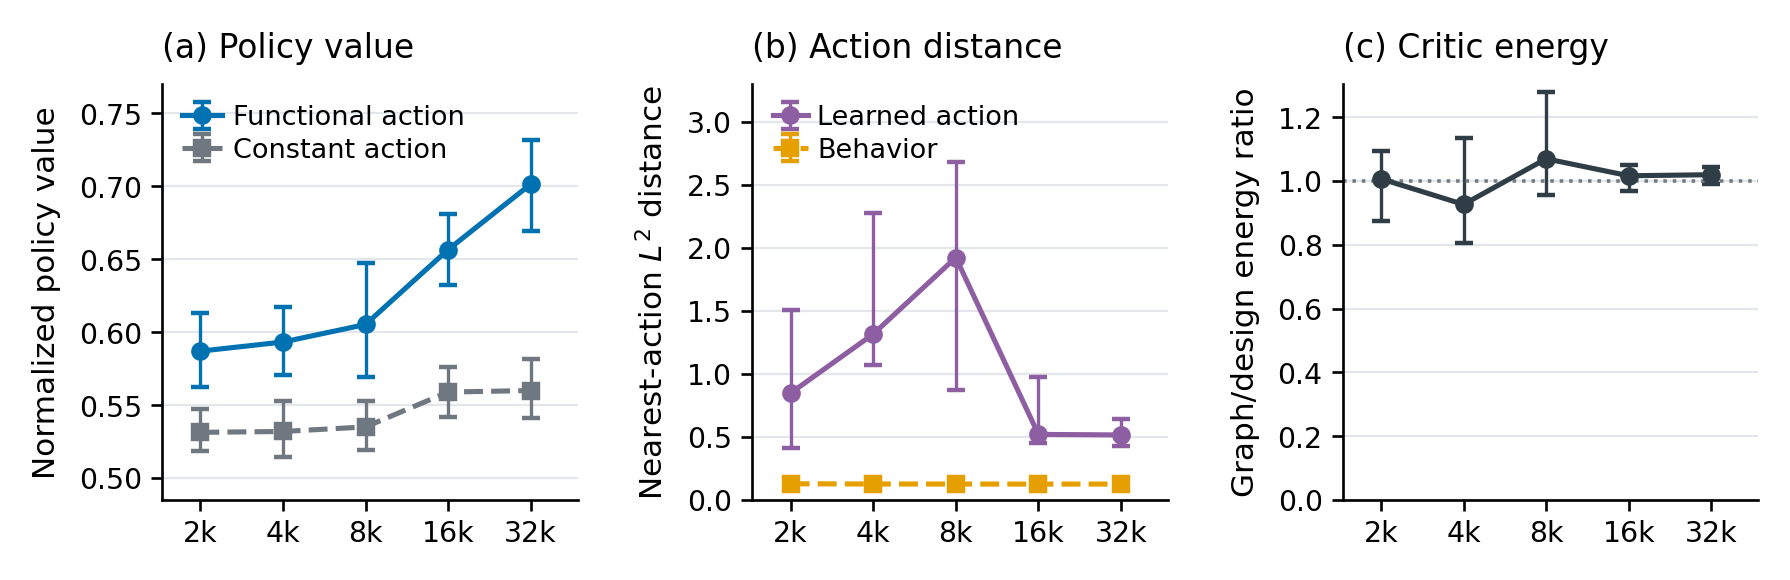

In [7]:
# Generate all six figures and display the combined main-text figure.
import contextlib
import io
from functional_fitted_q.analysis.reproduce import reproduce
with contextlib.redirect_stdout(io.StringIO()):
    reproduce(ROOT, SOURCE, ROOT / 'outputs')
display(Image(filename=str(ROOT / 'outputs/figures/main_figure.png'), width=900))

## What the figures show

These plots motivate critic-relative identification despite weak empirical action
proximity. They do not prove a uniform population coverage assumption, identify
Q-star errors, or guarantee monotonic value as lambda or sample size increases.
This notebook uses the supplied results. Full retraining is a separate GPU
workflow. Fitted checkpoints and episode-level vectors are not included.